<a href="https://colab.research.google.com/github/SimJaeHeon3513/MyProject/blob/main/%ED%95%9C%EA%B5%AD%EC%96%B4_%EA%B0%90%EC%A0%95_%EB%B6%84%EB%A5%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 환경 세팅

In [ ]:
!pip install transformers datasets torch scikit-learn

### 데이터 준비

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

train_df = pd.read_csv("ratings_train.txt", sep = "\t").dropna()
test_df = pd.read_csv("ratings_test.txt", sep = "\t").dropna()

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "test": Dataset.from_pandas(test_df)
})

print(dataset)



--2026-03-16 12:46:05--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.1s    

2026-03-16 12:46:06 (111 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-03-16 12:46:06--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

#### Tokenizing

In [ ]:
from transformers import AutoTokenizer

# 한국어 → klue/bert-base, 영어 → bert-base-uncased
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["document"], truncation=True, padding="max_length", max_length=128)

tokenized = dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

### 모델 파인튜닝

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2)

training_args = TrainingArguments(
    output_dir = "./results",
    num_train_epochs = 3,
    per_device_train_batch_size = 32,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized["train"],
    eval_dataset = tokenized["test"]
)

trainer.train()

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Epoch,Training Loss,Validation Loss
1,0.251200,0.244476
2,0.167782,0.260030
3,0.094517,0.355413


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=14064, training_loss=0.18624241000827532, metrics={'train_runtime': 10374.8432, 'train_samples_per_second': 43.373, 'train_steps_per_second': 1.356, 'total_flos': 2.95990070615424e+16, 'train_loss': 0.18624241000827532, 'epoch': 3.0})

### 평가 & 시각화

              precision    recall  f1-score   support

          부정       0.91      0.89      0.90     24826
          긍정       0.89      0.91      0.90     25171

    accuracy                           0.90     49997
   macro avg       0.90      0.90      0.90     49997
weighted avg       0.90      0.90      0.90     49997



<function matplotlib.pyplot.show(close=None, block=None)>

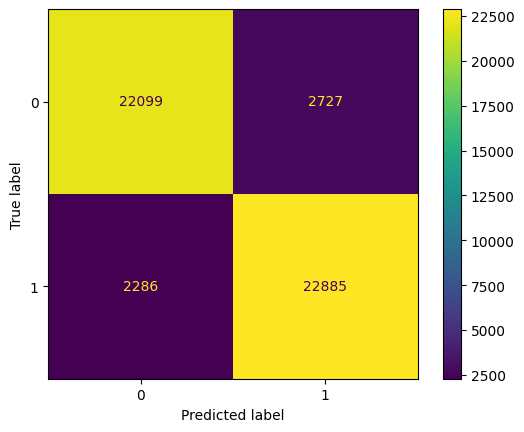

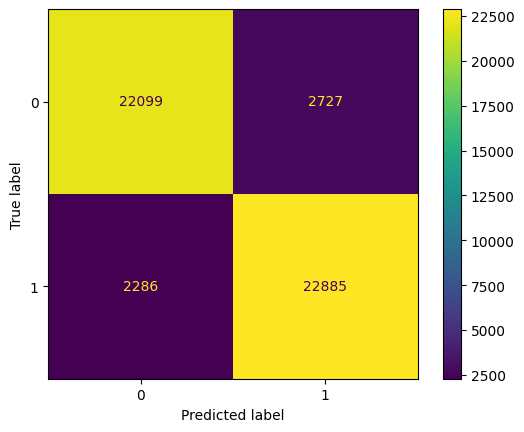

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized["test"])
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names = ["부정", "긍정"]))
ConfusionMatrixDisplay.from_predictions(labels, preds).plot()
plt.show

